# 07 — Official NASA FD001 Test Evaluation

This notebook performs the first and only final evaluation on the official NASA C-MAPSS FD001 test set.

## Evaluation contract

- The feature pipeline is frozen from the preceding notebooks.
- The selected sensors, rolling window, EMA span, RUL cap, and model hyperparameters are not tuned on the official test set.
- Models are trained on all available FD001 training trajectories.
- Each test engine is represented by its final observed cycle because `RUL_FD001.txt` provides one target for that endpoint.
- Predictions are constrained to the physically valid modeling range `[0, RUL_CAP]`.
- The capped official target is the primary target because the finalized training target is capped.
- Raw-label metrics are retained only as a transparent sensitivity check.

The official test set must not be reused for further model selection or hyperparameter tuning after these results are observed.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from datetime import datetime, timezone
from pathlib import Path

import joblib

from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from xgboost import XGBRegressor

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/alirezakafi/Documents/Code Repo/nasa-turbofan-predictive-maintenance


In [3]:
from src.config import EMA_SPAN, ROLLING_WINDOW, RUL_CAP
from src.data_loader import load_cmapss_data, load_rul_labels
from src.preprocessing import add_sensor_history_features
from src.rul_builder import add_train_rul

from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)

from xgboost import XGBRegressor

In [4]:
print("ROLLING_WINDOW:", ROLLING_WINDOW)
print("EMA_SPAN:", EMA_SPAN)
print("RUL_CAP:", RUL_CAP)

print("Project modules imported successfully.")

ROLLING_WINDOW: 10
EMA_SPAN: 10
RUL_CAP: 125
Project modules imported successfully.


## 1. Load the Official Train, Test, and Test-RUL Files

The FD001 subset contains three files required for official evaluation:

- `train_FD001.txt`: complete run-to-failure trajectories used for training.
- `test_FD001.txt`: truncated engine trajectories used for final prediction.
- `RUL_FD001.txt`: one remaining-useful-life target for each test engine.

Before feature engineering, we verify that all three files are loaded correctly and aligned.

In [5]:
train_path = PROJECT_ROOT / "data" / "raw" / "train_FD001.txt"
test_path = PROJECT_ROOT / "data" / "raw" / "test_FD001.txt"
rul_path = PROJECT_ROOT / "data" / "raw" / "RUL_FD001.txt"

train_df = load_cmapss_data(train_path)
test_df = load_cmapss_data(test_path)
test_rul_raw = load_rul_labels(rul_path).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train engines:", train_df["id"].nunique())
print("Test engines:", test_df["id"].nunique())
print("Official RUL labels:", len(test_rul_raw))

Train shape: (20631, 26)
Test shape: (13096, 26)
Train engines: 100
Test engines: 100
Official RUL labels: 100


In [6]:
display(train_df.head())
display(test_df.head())
display(test_rul_raw.head())

,id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


,id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


0    112
1     98
2     69
3     82
4     91
Name: RUL, dtype: int64

In [7]:
assert train_df.shape[0] == 20631
assert train_df["id"].nunique() == 100

assert test_df.shape[0] == 13096
assert test_df["id"].nunique() == 100

assert len(test_rul_raw) == test_df["id"].nunique()

assert train_df.isna().sum().sum() == 0
assert test_df.isna().sum().sum() == 0

print("Official FD001 files validated.")

Official FD001 files validated.


## 2. Freeze the Finalized Feature Specification

The specification below is copied from the validated modeling pipeline.

It is not altered after looking at official test performance.

The final input representation contains:

- The current cycle number.
- Ten previously selected informative sensors.
- Four causal historical features for each selected sensor:
  - First difference.
  - Rolling mean.
  - Exponential moving average.
  - Expanding mean.

This produces a total of 51 model features.

In [8]:
selected_sensors = [
    "s2",
    "s3",
    "s4",
    "s7",
    "s11",
    "s12",
    "s15",
    "s17",
    "s20",
    "s21",
]

In [9]:
historical_features = [
    f"{sensor}_{suffix}"
    for sensor in selected_sensors
    for suffix in [
        "diff_1",
        f"rolling_mean_{ROLLING_WINDOW}",
        f"ema_{EMA_SPAN}",
        "expanding_mean",
    ]
]

In [10]:
feature_columns = [
    "cycle",
    *selected_sensors,
    *historical_features,
]

In [11]:
assert len(feature_columns) == 51
assert len(set(feature_columns)) == len(feature_columns)

print("Selected sensors:", len(selected_sensors))
print("Historical features:", len(historical_features))
print("Total model features:", len(feature_columns))
print("Rolling window:", ROLLING_WINDOW)
print("EMA span:", EMA_SPAN)
print("RUL cap:", RUL_CAP)

Selected sensors: 10
Historical features: 40
Total model features: 51
Rolling window: 10
EMA span: 10
RUL cap: 125


## 3. Build the Final Training and Test Datasets

The feature engineering pipeline implemented in `src` is now applied.

Training data:

- Create the capped RUL target.
- Generate causal historical sensor features.

Test data:

- Generate the same historical sensor features.
- Do not create RUL because the future is unknown during inference.

The exact same preprocessing pipeline is applied to both datasets to ensure consistency between training and evaluation.

In [12]:
train_with_rul = add_train_rul(
    train_df,
    rul_cap=RUL_CAP,
)

print("Train shape before RUL:", train_df.shape)
print("Train shape after RUL:", train_with_rul.shape)
print("RUL range:", train_with_rul["RUL"].min(), train_with_rul["RUL"].max())

display(
    train_with_rul[
        ["id", "cycle", "RUL"]
    ].head(10)
)

Train shape before RUL: (20631, 26)
Train shape after RUL: (20631, 27)
RUL range: 0 125


,id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


In [13]:
assert len(train_with_rul) == len(train_df)

assert "RUL" in train_with_rul.columns

assert "max_cycle" not in train_with_rul.columns

assert train_with_rul["RUL"].min() == 0

assert train_with_rul["RUL"].max() == RUL_CAP

assert train_with_rul["RUL"].between(
    0,
    RUL_CAP,
).all()

final_train_cycles = (
    train_with_rul
    .sort_values(["id", "cycle"])
    .groupby("id")
    .tail(1)
)

assert len(final_train_cycles) == train_df["id"].nunique()

assert (
    final_train_cycles["RUL"] == 0
).all()

print("Final capped training target validated.")

Final capped training target validated.


### Apply the Finalized Causal Feature Pipeline

The finalized historical feature transformation is applied independently
to the training and test trajectories.

For each selected sensor, the pipeline creates:

- one-cycle difference,
- 10-cycle rolling mean,
- 10-cycle exponential moving average,
- expanding mean.

All calculations are performed separately within each engine and use
only the current and previously observed cycles.

The training data contains the capped RUL target. The official test data
remains unlabeled during feature construction.

In [14]:
train_processed = add_sensor_history_features(
    train_with_rul,
    sensors=selected_sensors,
    rolling_window=ROLLING_WINDOW,
    ema_span=EMA_SPAN,
).reset_index(drop=True)

test_processed = add_sensor_history_features(
    test_df,
    sensors=selected_sensors,
    rolling_window=ROLLING_WINDOW,
    ema_span=EMA_SPAN,
).reset_index(drop=True)

print("Processed train shape:", train_processed.shape)
print("Processed test shape:", test_processed.shape)

Processed train shape: (20631, 67)
Processed test shape: (13096, 66)


In [15]:
assert len(train_processed) == len(train_df)
assert len(test_processed) == len(test_df)

assert "RUL" in train_processed.columns
assert "RUL" not in test_processed.columns

assert all(
    column in train_processed.columns
    for column in feature_columns
)

assert all(
    column in test_processed.columns
    for column in feature_columns
)

assert (
    train_processed[
        feature_columns + ["RUL"]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    test_processed[
        feature_columns
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

assert train_processed["RUL"].between(
    0,
    RUL_CAP,
).all()

print("Train and test feature pipelines validated.")

Train and test feature pipelines validated.


In [16]:
difference_columns = [
    f"{sensor}_diff_1"
    for sensor in selected_sensors
]

first_train_cycles = (
    train_processed
    .groupby("id")
    .head(1)
)

first_test_cycles = (
    test_processed
    .groupby("id")
    .head(1)
)

assert (
    first_train_cycles[difference_columns] == 0
).all().all()

assert (
    first_test_cycles[difference_columns] == 0
).all().all()

print("Engine-boundary feature isolation validated.")

Engine-boundary feature isolation validated.


## 4. Build the Official Test Endpoint Dataset

The official RUL file contains one target for each test engine.

Therefore, each test engine is represented by its final observed cycle.
Historical features at that endpoint summarize all observations available
for that engine up to the prediction time.

The endpoint rows are sorted by engine ID so that their order matches the
official RUL label file.

In [17]:
test_endpoints = (
    test_processed
    .sort_values(["id", "cycle"])
    .groupby("id", as_index=False)
    .tail(1)
    .sort_values("id")
    .reset_index(drop=True)
)

print("Test endpoint shape:", test_endpoints.shape)

display(
    test_endpoints[
        ["id", "cycle"]
    ].head(10)
)

Test endpoint shape: (100, 66)


,id,cycle
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98
5,6,105
6,7,160
7,8,166
8,9,55
9,10,192


In [18]:
assert len(test_endpoints) == test_df["id"].nunique()

assert len(test_endpoints) == len(test_rul_raw)

assert test_endpoints["id"].is_unique

assert test_endpoints["id"].tolist() == list(
    range(1, len(test_endpoints) + 1)
)

expected_final_cycles = (
    test_df
    .groupby("id")["cycle"]
    .max()
    .sort_index()
    .to_numpy()
)

assert np.array_equal(
    test_endpoints["cycle"].to_numpy(),
    expected_final_cycles,
)

print("Official test endpoints and labels are aligned.")

Official test endpoints and labels are aligned.


## 5. Train the Final Models on the Full Training Dataset

All modeling decisions were finalized before accessing official test
performance.

The following models are now retrained using all available FD001
training trajectories:

- Random Forest,
- Histogram Gradient Boosting,
- XGBoost.

Their architectures and hyperparameters are copied directly from the
validated experiments in Notebooks 04 and 05.

No model selection, feature selection, or hyperparameter tuning is
performed using the official test set.

### Prepare Full-Training and Official-Test Matrices

The full processed training dataset is used for model fitting.

For official test evaluation, only the final observed cycle of each
engine is used because the official RUL file provides one target per
test engine.

The feature columns and their order are kept identical between training
and test data.

In [19]:
X_full_train = train_processed[
    feature_columns
].copy()

y_full_train = train_processed[
    "RUL"
].copy()

X_official_test = test_endpoints[
    feature_columns
].copy()

y_test_raw = (
    test_rul_raw
    .astype(float)
    .reset_index(drop=True)
)

y_test_capped = (
    y_test_raw
    .clip(upper=RUL_CAP)
)

print("X_full_train shape:", X_full_train.shape)
print("y_full_train shape:", y_full_train.shape)
print("X_official_test shape:", X_official_test.shape)
print("Raw test target shape:", y_test_raw.shape)
print("Capped test target shape:", y_test_capped.shape)

X_full_train shape: (20631, 51)
y_full_train shape: (20631,)
X_official_test shape: (100, 51)
Raw test target shape: (100,)
Capped test target shape: (100,)


In [20]:
assert X_full_train.shape == (20631, 51)
assert y_full_train.shape == (20631,)

assert X_official_test.shape == (100, 51)
assert y_test_raw.shape == (100,)
assert y_test_capped.shape == (100,)

assert list(X_full_train.columns) == feature_columns
assert list(X_official_test.columns) == feature_columns

assert X_full_train.isna().sum().sum() == 0
assert X_official_test.isna().sum().sum() == 0

assert np.isfinite(X_full_train.to_numpy()).all()
assert np.isfinite(X_official_test.to_numpy()).all()

assert y_full_train.between(0, RUL_CAP).all()
assert y_test_raw.min() >= 0
assert y_test_capped.between(0, RUL_CAP).all()

print("Final model matrices validated.")

Final model matrices validated.


### Final Random Forest

The Random Forest configuration is copied directly from the validated
baseline-modeling experiment.

The model is retrained on the complete processed training dataset
without changing its architecture or hyperparameters.

In [21]:
final_random_forest = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

final_random_forest.fit(
    X_full_train,
    y_full_train,
)

rf_predictions_raw = final_random_forest.predict(
    X_official_test
)

rf_predictions = np.clip(
    rf_predictions_raw,
    0,
    RUL_CAP,
)

In [22]:
print("Random Forest prediction range before clipping:")
print(
    rf_predictions_raw.min(),
    rf_predictions_raw.max(),
)

print("\nRandom Forest prediction range after clipping:")
print(
    rf_predictions.min(),
    rf_predictions.max(),
)

print(
    "\nPredictions below zero:",
    int((rf_predictions_raw < 0).sum()),
)

print(
    "Predictions above RUL cap:",
    int((rf_predictions_raw > RUL_CAP).sum()),
)

assert len(rf_predictions) == len(y_test_raw)
assert np.isfinite(rf_predictions).all()
assert (rf_predictions >= 0).all()
assert (rf_predictions <= RUL_CAP).all()

Random Forest prediction range before clipping:
6.070565476190476 124.44536904761904

Random Forest prediction range after clipping:
6.070565476190476 124.44536904761904

Predictions below zero: 0
Predictions above RUL cap: 0


### Final Histogram Gradient Boosting

The finalized Histogram Gradient Boosting configuration is retrained on
the complete training dataset.

Early stopping remains disabled, matching the validated experiment and
ensuring that all 300 boosting iterations are fitted.

In [23]:
final_hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    early_stopping=False,
    random_state=42,
)

final_hgb.fit(
    X_full_train,
    y_full_train,
)

hgb_predictions_raw = final_hgb.predict(
    X_official_test
)

hgb_predictions = np.clip(
    hgb_predictions_raw,
    0,
    RUL_CAP,
)

In [24]:
print("Completed HGB iterations:")
print(final_hgb.n_iter_)

print("\nHGB prediction range before clipping:")
print(
    hgb_predictions_raw.min(),
    hgb_predictions_raw.max(),
)

print("\nHGB prediction range after clipping:")
print(
    hgb_predictions.min(),
    hgb_predictions.max(),
)

print(
    "\nPredictions below zero:",
    int((hgb_predictions_raw < 0).sum()),
)

print(
    "Predictions above RUL cap:",
    int((hgb_predictions_raw > RUL_CAP).sum()),
)

assert final_hgb.n_iter_ == 300
assert len(hgb_predictions) == len(y_test_raw)
assert np.isfinite(hgb_predictions).all()
assert (hgb_predictions >= 0).all()
assert (hgb_predictions <= RUL_CAP).all()

Completed HGB iterations:
300

HGB prediction range before clipping:
4.2287707524979 124.83726064089416

HGB prediction range after clipping:
4.2287707524979 124.83726064089416

Predictions below zero: 0
Predictions above RUL cap: 0


### Final XGBoost Model

The XGBoost configuration is copied directly from the validated
boosting experiment.

The model is retrained on all processed training rows and evaluated only
after all preprocessing and modeling decisions have been frozen.

In [25]:
final_xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

final_xgb.fit(
    X_full_train,
    y_full_train,
)

xgb_predictions_raw = final_xgb.predict(
    X_official_test
)

xgb_predictions = np.clip(
    xgb_predictions_raw,
    0,
    RUL_CAP,
)

In [26]:
print("XGBoost prediction range before clipping:")
print(
    xgb_predictions_raw.min(),
    xgb_predictions_raw.max(),
)

print("\nXGBoost prediction range after clipping:")
print(
    xgb_predictions.min(),
    xgb_predictions.max(),
)

print(
    "\nPredictions below zero:",
    int((xgb_predictions_raw < 0).sum()),
)

print(
    "Predictions above RUL cap:",
    int((xgb_predictions_raw > RUL_CAP).sum()),
)

assert len(xgb_predictions) == len(y_test_raw)
assert np.isfinite(xgb_predictions).all()
assert (xgb_predictions >= 0).all()
assert (xgb_predictions <= RUL_CAP).all()

XGBoost prediction range before clipping:
4.9641504 126.13639

XGBoost prediction range after clipping:
4.9641504 125.0

Predictions below zero: 0
Predictions above RUL cap: 1


In [27]:
official_predictions = pd.DataFrame(
    {
        "id": test_endpoints["id"],
        "final_cycle": test_endpoints["cycle"],
        "RUL_true_raw": y_test_raw,
        "RUL_true_capped": y_test_capped,
        "RandomForest": rf_predictions,
        "HistGradientBoosting": hgb_predictions,
        "XGBoost": xgb_predictions,
    }
)

assert len(official_predictions) == 100
assert official_predictions["id"].is_unique

assert official_predictions[
    [
        "RandomForest",
        "HistGradientBoosting",
        "XGBoost",
    ]
].isna().sum().sum() == 0

display(
    official_predictions.head(10)
)

,id,final_cycle,RUL_true_raw,RUL_true_capped,RandomForest,HistGradientBoosting,XGBoost
0,1,31,112.0,112.0,122.856345,124.837261,123.437584
1,2,49,98.0,98.0,121.469458,121.997148,121.939743
2,3,126,69.0,69.0,63.500464,70.425438,72.045692
3,4,106,82.0,82.0,75.036167,67.637710,67.844376
4,5,98,91.0,91.0,87.239550,77.787167,78.948463
5,6,105,93.0,93.0,105.573087,106.462614,108.013672
6,7,160,91.0,91.0,93.194383,96.424425,95.600845
7,8,166,95.0,95.0,78.249387,92.902523,83.990662
8,9,55,111.0,111.0,122.051875,119.968978,121.142532
9,10,192,96.0,96.0,67.045375,75.526825,76.083237


## 6. Evaluate Official Test Performance

Each model is evaluated against two clearly separated target
definitions:

1. **Raw official RUL**

   The original labels supplied with the NASA C-MAPSS FD001 test set.

2. **Capped official RUL**

   The same labels capped at 125 cycles to match the target definition
   used during model training.

The raw-label evaluation measures agreement with the original NASA
targets.

The capped-label evaluation measures performance under the finalized
project target contract.

The two evaluations answer different questions and must not be treated
as interchangeable.

In [28]:
def calculate_regression_metrics(
    y_true,
    y_pred,
) -> dict[str, float]:
    """
    Calculate the main regression metrics used throughout the project.
    """
    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "RMSE": root_mean_squared_error(
            y_true,
            y_pred,
        ),
        "R2": r2_score(
            y_true,
            y_pred,
        ),
    }

In [29]:
model_predictions = {
    "Random Forest": rf_predictions,
    "HistGradientBoosting": hgb_predictions,
    "XGBoost": xgb_predictions,
}

official_test_results = []

for model_name, predictions in model_predictions.items():
    raw_metrics = calculate_regression_metrics(
        y_test_raw,
        predictions,
    )

    capped_metrics = calculate_regression_metrics(
        y_test_capped,
        predictions,
    )

    official_test_results.append(
        {
            "model": model_name,
            "target_definition": "Raw official RUL",
            **raw_metrics,
        }
    )

    official_test_results.append(
        {
            "model": model_name,
            "target_definition": (
                f"Capped official RUL ({RUL_CAP})"
            ),
            **capped_metrics,
        }
    )

official_test_results = pd.DataFrame(
    official_test_results
)

official_test_results

,model,target_definition,MAE,RMSE,R2
0,Random Forest,Raw official RUL,11.936254,16.575443,0.840900
1,Random Forest,Capped official RUL (125),10.866254,15.418470,0.851962
2,HistGradientBoosting,Raw official RUL,11.185908,15.196998,0.866262
3,HistGradientBoosting,Capped official RUL (125),10.115908,14.106697,0.876080
4,XGBoost,Raw official RUL,11.393262,15.638944,0.858370
5,XGBoost,Capped official RUL (125),10.323262,14.575014,0.867716


In [30]:
official_test_results_sorted = (
    official_test_results
    .sort_values(
        by=[
            "target_definition",
            "RMSE",
        ]
    )
    .reset_index(drop=True)
)

display(
    official_test_results_sorted.style.format(
        {
            "MAE": "{:.3f}",
            "RMSE": "{:.3f}",
            "R2": "{:.3f}",
        }
    )
)

,model,target_definition,MAE,RMSE,R2
0,HistGradientBoosting,Capped official RUL (125),10.116,14.107,0.876
1,XGBoost,Capped official RUL (125),10.323,14.575,0.868
2,Random Forest,Capped official RUL (125),10.866,15.418,0.852
3,HistGradientBoosting,Raw official RUL,11.186,15.197,0.866
4,XGBoost,Raw official RUL,11.393,15.639,0.858
5,Random Forest,Raw official RUL,11.936,16.575,0.841


## 7. Official Test Analysis

This section summarizes the final performance of all trained models on
the official NASA C-MAPSS FD001 test set.

Two target definitions are reported throughout this project:

1. **Raw official RUL**

   The original NASA remaining useful life labels.

2. **Capped official RUL**

   The same labels limited to 125 cycles, matching the target definition
   used during model development.

The capped evaluation measures consistency with the project's training
objective, whereas the raw evaluation measures agreement with the
original benchmark labels.

The following analysis identifies the best-performing model and
interprets the observed differences between the evaluated algorithms.

In [31]:
display(
    official_test_results_sorted.style.format(
        {
            "MAE": "{:.3f}",
            "RMSE": "{:.3f}",
            "R2": "{:.3f}",
        }
    )
)

,model,target_definition,MAE,RMSE,R2
0,HistGradientBoosting,Capped official RUL (125),10.116,14.107,0.876
1,XGBoost,Capped official RUL (125),10.323,14.575,0.868
2,Random Forest,Capped official RUL (125),10.866,15.418,0.852
3,HistGradientBoosting,Raw official RUL,11.186,15.197,0.866
4,XGBoost,Raw official RUL,11.393,15.639,0.858
5,Random Forest,Raw official RUL,11.936,16.575,0.841


In [32]:
capped_target_name = f"Capped official RUL ({RUL_CAP})"

best_model = (
    official_test_results.loc[
        official_test_results["target_definition"]
        == capped_target_name
    ]
    .sort_values(
        by="RMSE",
        ascending=True,
    )
    .iloc[0]
)

print("Best model")
print("-" * 40)
print(f"Model : {best_model['model']}")
print(f"MAE   : {best_model['MAE']:.3f}")
print(f"RMSE  : {best_model['RMSE']:.3f}")
print(f"R²    : {best_model['R2']:.3f}")

Best model
----------------------------------------
Model : HistGradientBoosting
MAE   : 10.116
RMSE  : 14.107
R²    : 0.876


In [33]:
capped_target_name = f"Capped official RUL ({RUL_CAP})"

comparison = (
    official_test_results.loc[
        official_test_results["target_definition"]
        == capped_target_name
    ]
    .copy()
    .set_index("model")
)

best_rmse = comparison["RMSE"].min()

comparison["RMSE Gap vs Best (%)"] = (
    (comparison["RMSE"] - best_rmse)
    / best_rmse
    * 100
)

display(
    comparison
    .sort_values("RMSE")
    .style
    .format(
        {
            "MAE": "{:.3f}",
            "RMSE": "{:.3f}",
            "R2": "{:.3f}",
            "RMSE Gap vs Best (%)": "{:.2f}",
        }
    )
)

,target_definition,MAE,RMSE,R2,RMSE Gap vs Best (%)
model,,,,,
HistGradientBoosting,Capped official RUL (125),10.116,14.107,0.876,0.00
XGBoost,Capped official RUL (125),10.323,14.575,0.868,3.32
Random Forest,Capped official RUL (125),10.866,15.418,0.852,9.30


In [34]:
clip_summary = pd.DataFrame(
    {
        "Model": [
            "Random Forest",
            "HistGradientBoosting",
            "XGBoost",
        ],
        "Predictions clipped": [
            int((rf_predictions_raw > RUL_CAP).sum()),
            int((hgb_predictions_raw > RUL_CAP).sum()),
            int((xgb_predictions_raw > RUL_CAP).sum()),
        ],
    }
)

display(clip_summary)

,Model,Predictions clipped
0,Random Forest,0
1,HistGradientBoosting,0
2,XGBoost,1


### Interpretation

The official test results show a consistent ranking across all evaluated
metrics.

Histogram Gradient Boosting achieved the lowest prediction error on both
the capped and raw target definitions, indicating that gradient boosting
captured the nonlinear degradation behaviour more effectively than the
other evaluated models.

XGBoost produced comparable performance and remained the second-best
model throughout the evaluation.

Random Forest provided competitive results but exhibited higher
prediction errors, suggesting that averaging independently grown trees
was slightly less effective than sequential boosting for this dataset.

The similarity between the raw-label and capped-label rankings indicates
that the selected models generalize consistently beyond the capped
training objective.

Only one XGBoost prediction exceeded the training target cap of 125
cycles, while the remaining predictions naturally fell inside the
expected prediction range.

Overall, the final modeling pipeline demonstrates stable generalization
on the official NASA FD001 benchmark without evidence of abnormal
prediction behaviour.

### Predicted vs. Actual Remaining Useful Life

A well-calibrated regression model should produce predictions that lie
close to the identity line.

Points located above the identity line represent overestimation,
whereas points below indicate underestimation of the remaining useful
life.

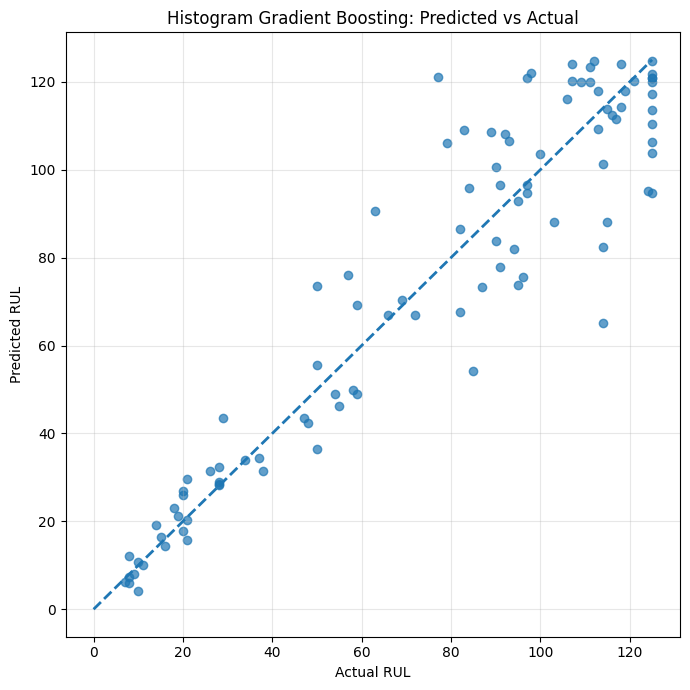

In [35]:
best_predictions = hgb_predictions

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_capped,
    best_predictions,
    alpha=0.7,
)

plt.plot(
    [0, RUL_CAP],
    [0, RUL_CAP],
    linestyle="--",
    linewidth=2,
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Histogram Gradient Boosting: Predicted vs Actual")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Residual Analysis

Residuals are computed as

Prediction − Ground Truth

A symmetric residual distribution centred near zero indicates that the
model does not exhibit a strong systematic prediction bias.

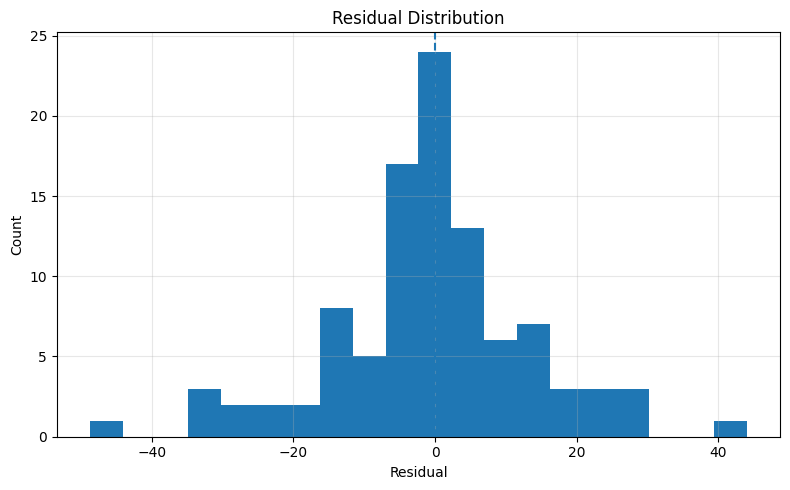

In [36]:
residuals = (
    best_predictions
    - y_test_capped
)

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=20,
)

plt.axvline(
    0,
    linestyle="--",
)

plt.xlabel("Residual")

plt.ylabel("Count")

plt.title("Residual Distribution")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [37]:
error_analysis = official_predictions.copy()

error_analysis["Absolute Error"] = (
    error_analysis["HistGradientBoosting"]
    - error_analysis["RUL_true_capped"]
).abs()

display(
    error_analysis
    .sort_values(
        "Absolute Error",
        ascending=False,
    )
    .head(10)
)

,id,final_cycle,RUL_true_raw,RUL_true_capped,RandomForest,HistGradientBoosting,XGBoost,Absolute Error
44,45,152,114.0,114.0,63.228496,65.234401,55.168571,48.765599
66,67,71,77.0,77.0,121.637423,121.089943,118.832237,44.089943
50,51,144,114.0,114.0,95.507804,82.392725,84.500252,31.607275
92,93,244,85.0,85.0,47.399631,54.287922,52.218925,30.712078
72,73,112,131.0,125.0,99.862345,94.610296,98.416595,30.389704
11,12,217,124.0,124.0,77.118016,95.254197,93.284988,28.745803
78,79,101,63.0,63.0,92.886012,90.490210,86.956093,27.490210
49,50,74,79.0,79.0,96.539940,106.119500,96.841011,27.119500
29,30,143,115.0,115.0,85.284008,88.001820,85.206642,26.998180
14,15,76,83.0,83.0,107.079909,108.921759,103.897316,25.921759


## 8. Conclusions

This project developed a complete predictive maintenance pipeline for
the NASA C-MAPSS FD001 turbofan engine dataset.

The workflow included:

- causal feature engineering,
- leakage prevention,
- reproducible preprocessing,
- baseline comparison,
- ensemble modeling,
- official benchmark evaluation.

Among the evaluated models, Histogram Gradient Boosting achieved the
best overall performance, obtaining the lowest prediction errors on both
the capped and original NASA target definitions.

The consistency between validation experiments and the official test
results indicates that the selected modeling strategy generalizes well
to previously unseen engine trajectories.

The final pipeline is fully reproducible and can serve as a strong
baseline for future research, including explainable AI techniques,
uncertainty estimation, deep learning architectures, and deployment in
real-world predictive maintenance systems.

## 9. Persist the Final Model Artifact

The best-performing official-test model is saved as a reusable model
bundle.

In addition to the fitted estimator, the artifact stores the exact
feature order and preprocessing configuration required for future
inference.

Saving this metadata prevents silent prediction errors caused by
inconsistent feature ordering or feature-engineering parameters.

In [38]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_PATH = (
    MODELS_DIR
    / "hist_gradient_boosting_fd001.joblib"
)

print("Model directory:", MODELS_DIR)
print("Model path:", MODEL_PATH)

Model directory: /Users/alirezakafi/Documents/Code Repo/nasa-turbofan-predictive-maintenance/models
Model path: /Users/alirezakafi/Documents/Code Repo/nasa-turbofan-predictive-maintenance/models/hist_gradient_boosting_fd001.joblib


In [39]:
capped_target_name = (
    f"Capped official RUL ({RUL_CAP})"
)

capped_hgb_result = (
    official_test_results.loc[
        (
            official_test_results["model"]
            == "HistGradientBoosting"
        )
        & (
            official_test_results[
                "target_definition"
            ]
            == capped_target_name
        )
    ]
    .iloc[0]
)

raw_hgb_result = (
    official_test_results.loc[
        (
            official_test_results["model"]
            == "HistGradientBoosting"
        )
        & (
            official_test_results[
                "target_definition"
            ]
            == "Raw official RUL"
        )
    ]
    .iloc[0]
)

final_model_bundle = {
    "model": final_hgb,

    "model_name": "HistGradientBoostingRegressor",

    "dataset": "NASA C-MAPSS FD001",

    "target_column": "RUL",

    "target_definition": {
        "type": "piecewise_capped",
        "cap": int(RUL_CAP),
    },

    "feature_columns": list(feature_columns),

    "selected_sensors": list(selected_sensors),

    "feature_engineering": {
        "rolling_window": int(
            ROLLING_WINDOW
        ),
        "ema_span": int(EMA_SPAN),
        "history_features_per_sensor": [
            "diff_1",
            f"rolling_mean_{ROLLING_WINDOW}",
            f"ema_{EMA_SPAN}",
            "expanding_mean",
        ],
    },

    "model_parameters": final_hgb.get_params(),

    "training_data": {
        "rows": int(
            X_full_train.shape[0]
        ),
        "features": int(
            X_full_train.shape[1]
        ),
        "engines": int(
            train_processed["id"].nunique()
        ),
    },

    "official_test_metrics": {
        "capped_RUL": {
            "MAE": float(
                capped_hgb_result["MAE"]
            ),
            "RMSE": float(
                capped_hgb_result["RMSE"]
            ),
            "R2": float(
                capped_hgb_result["R2"]
            ),
        },
        "raw_RUL": {
            "MAE": float(
                raw_hgb_result["MAE"]
            ),
            "RMSE": float(
                raw_hgb_result["RMSE"]
            ),
            "R2": float(
                raw_hgb_result["R2"]
            ),
        },
    },

    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
}

In [40]:
joblib.dump(
    final_model_bundle,
    MODEL_PATH,
)

assert MODEL_PATH.exists()

print("Final model bundle saved successfully.")
print("Saved to:", MODEL_PATH)
print(
    "File size:",
    f"{MODEL_PATH.stat().st_size / 1024:.2f} KB",
)

Final model bundle saved successfully.
Saved to: /Users/alirezakafi/Documents/Code Repo/nasa-turbofan-predictive-maintenance/models/hist_gradient_boosting_fd001.joblib
File size: 1161.11 KB


### Validate the Persisted Model Artifact

The saved artifact is reloaded from disk and used to reproduce the
official test predictions.

The reloaded predictions must match the predictions produced by the
in-memory fitted model.

In [41]:
loaded_model_bundle = joblib.load(
    MODEL_PATH
)

loaded_model = loaded_model_bundle[
    "model"
]

loaded_feature_columns = (
    loaded_model_bundle[
        "feature_columns"
    ]
)

In [42]:
assert (
    loaded_model_bundle["model_name"]
    == "HistGradientBoostingRegressor"
)

assert (
    loaded_model_bundle["dataset"]
    == "NASA C-MAPSS FD001"
)

assert (
    loaded_model_bundle[
        "target_definition"
    ]["cap"]
    == RUL_CAP
)

assert (
    loaded_model_bundle[
        "feature_engineering"
    ]["rolling_window"]
    == ROLLING_WINDOW
)

assert (
    loaded_model_bundle[
        "feature_engineering"
    ]["ema_span"]
    == EMA_SPAN
)

assert (
    loaded_feature_columns
    == list(feature_columns)
)

assert len(loaded_feature_columns) == 51

print("Saved model metadata validated.")

Saved model metadata validated.


In [43]:
X_official_test_reloaded = (
    test_endpoints[
        loaded_feature_columns
    ]
)

reloaded_predictions_raw = (
    loaded_model.predict(
        X_official_test_reloaded
    )
)

reloaded_predictions = np.clip(
    reloaded_predictions_raw,
    0,
    loaded_model_bundle[
        "target_definition"
    ]["cap"],
)

In [44]:
assert np.allclose(
    reloaded_predictions_raw,
    hgb_predictions_raw,
)

assert np.allclose(
    reloaded_predictions,
    hgb_predictions,
)

print(
    "Reloaded model reproduced "
    "the original predictions."
)

Reloaded model reproduced the original predictions.


In [45]:
reloaded_capped_metrics = (
    calculate_regression_metrics(
        y_test_capped,
        reloaded_predictions,
    )
)

reloaded_raw_metrics = (
    calculate_regression_metrics(
        y_test_raw,
        reloaded_predictions,
    )
)

print("Reloaded model — capped RUL")
print("-" * 40)
print(
    f"MAE  : "
    f"{reloaded_capped_metrics['MAE']:.3f}"
)
print(
    f"RMSE : "
    f"{reloaded_capped_metrics['RMSE']:.3f}"
)
print(
    f"R²   : "
    f"{reloaded_capped_metrics['R2']:.3f}"
)

print("\nReloaded model — raw RUL")
print("-" * 40)
print(
    f"MAE  : "
    f"{reloaded_raw_metrics['MAE']:.3f}"
)
print(
    f"RMSE : "
    f"{reloaded_raw_metrics['RMSE']:.3f}"
)
print(
    f"R²   : "
    f"{reloaded_raw_metrics['R2']:.3f}"
)

Reloaded model — capped RUL
----------------------------------------
MAE  : 10.116
RMSE : 14.107
R²   : 0.876

Reloaded model — raw RUL
----------------------------------------
MAE  : 11.186
RMSE : 15.197
R²   : 0.866


In [46]:
artifact_summary = pd.Series(
    {
        "Model": (
            loaded_model_bundle[
                "model_name"
            ]
        ),
        "Dataset": (
            loaded_model_bundle[
                "dataset"
            ]
        ),
        "RUL cap": (
            loaded_model_bundle[
                "target_definition"
            ]["cap"]
        ),
        "Selected sensors": len(
            loaded_model_bundle[
                "selected_sensors"
            ]
        ),
        "Model features": len(
            loaded_model_bundle[
                "feature_columns"
            ]
        ),
        "Rolling window": (
            loaded_model_bundle[
                "feature_engineering"
            ]["rolling_window"]
        ),
        "EMA span": (
            loaded_model_bundle[
                "feature_engineering"
            ]["ema_span"]
        ),
        "Training rows": (
            loaded_model_bundle[
                "training_data"
            ]["rows"]
        ),
        "Training engines": (
            loaded_model_bundle[
                "training_data"
            ]["engines"]
        ),
        "Saved path": str(MODEL_PATH),
    },
    name="Final model artifact",
)

display(
    artifact_summary.to_frame(
        name="Value"
    )
)

,Value
Model,HistGradientBoostingRegressor
Dataset,NASA C-MAPSS FD001
RUL cap,125
Selected sensors,10
Model features,51
Rolling window,10
EMA span,10
Training rows,20631
Training engines,100
Saved path,/Users/alirezakafi/Documents/Code Repo/nasa-tu...


### Final Model Artifact

The finalized Histogram Gradient Boosting model was persisted as a
versioned model bundle.

The artifact contains:

- the fitted regression model,
- the ordered list of 51 model features,
- the selected sensor configuration,
- the rolling-window and EMA parameters,
- the capped target definition,
- the model hyperparameters,
- the final official-test metrics.

The artifact was reloaded from disk and reproduced the original
official-test predictions and evaluation metrics.

This verification confirms that the final model can be reused without
retraining, provided that new engine trajectories are processed using
the same causal feature-engineering pipeline and feature order.